# **Day 2.2: Learning Mechanisms**
**Module Theme:** How Neural Networks Learn from Mistakes  
**Estimated Time:** 1.0 hour  
**Prerequisites:** Note 2.1 - Multi-Layer Perceptrons

In [26]:
%%html
<style>
.jp-RenderedMarkdown table {
    font-size: 16px !important;
    line-height: 1.6 !important;
    border-collapse: collapse !important;
    width: 100% !important;
    margin: 20px 0 !important;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif !important;
}

.jp-RenderedMarkdown table th {
    background-color: #2c3e50 !important;
    color: white !important;
    padding: 15px 20px !important;
    text-align: left !important;
    font-weight: 600 !important;
    font-size: 16px !important;
    border: none !important;
}

.jp-RenderedMarkdown table td {
    padding: 15px 20px !important;
    border: none !important;
    border-bottom: 1px solid #e0e0e0 !important;
    vertical-align: top !important;
}

.jp-RenderedMarkdown table tr:nth-child(even) {
    background-color: #f8f9fa !important;
}

.jp-RenderedMarkdown table tr:nth-child(odd) {
    background-color: white !important;
}

.jp-RenderedMarkdown table tr:hover {
    background-color: #e3f2fd !important;
}

/* Style the first column differently */
.jp-RenderedMarkdown table td:first-child {
    font-weight: 600 !important;
    color: #2c3e50 !important;
    background-color: #f5f5f5 !important;
}

.jp-RenderedMarkdown table tr:nth-child(even) td:first-child {
    background-color: #eeeeee !important;
}
</style>

## **📚 Table of Contents**
- [2.2.1 Loss Functions: MSE, Binary/Categorical Crossentropy](#221-loss-functions-mse-binarycategorical-crossentropy)
- [2.2.2 Backpropagation: Conceptual Intuition](#222-backpropagation-conceptual-intuition)
- [2.2.3 Why These Loss Functions Work](#223-why-these-loss-functions-work)
- [Summary & Transition to Note 2.3](#summary--transition-to-note-23)

## **2.2.1 Loss Functions: MSE, Binary/Categorical Crossentropy**
*Estimated Time: 20 minutes*

### **🎯 The Learning Foundation: Measuring "Wrongness"**

A **Loss Function** (also called cost function or objective function) is the network's **report card**. It measures how "wrong" the model's prediction is compared to the true label. 

**The Golden Rule of Deep Learning:** The goal of training is to adjust weights and biases to **minimize this loss**.

### **🧭 Choosing the Right Loss Function: Your Navigation System**

The choice of loss function is **critical** and depends entirely on the type of problem you're solving. Pick the wrong loss function, and your model will optimize for the wrong thing!

#### 1. Mean Squared Error (MSE) 📈

**Definition**
Mean Squared Error measures the average of the squared differences between predicted and actual values. It penalizes larger errors more heavily due to the squaring operation, making it sensitive to outliers.

**Formula**
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y_i})^2$$

Where:
- $n$ = number of samples
- $y_i$ = actual value
- $\hat{y_i}$ = predicted value

**Keras Implementation**
```python
# Method 1: Using string identifier
model.compile(optimizer='adam', loss='mse')

# Method 2: Using function name
model.compile(optimizer='adam', loss='mean_squared_error')

# Method 3: Using function directly
from tensorflow.keras.losses import MeanSquaredError
model.compile(optimizer='adam', loss=MeanSquaredError())
```

**Example & Illustration**
**Scenario**: Predicting house prices

```python
import numpy as np
import matplotlib.pyplot as plt

# Example data
actual_prices = np.array([300000, 450000, 200000, 600000])
predicted_prices = np.array([320000, 430000, 180000, 580000])

# Calculate MSE manually
mse = np.mean((actual_prices - predicted_prices)**2)
print(f"MSE: {mse:,.0f}")

# Visualization concept
"""
If actual = 300k and predicted = 320k:
Error = 300k - 320k = -20k
Squared Error = (-20k)² = 400,000,000
"""
```

**Visual Representation**
```
Actual vs Predicted Prices:
Actual:    [300k] [450k] [200k] [600k]
Predicted: [320k] [430k] [180k] [580k]
Errors:    [-20k] [+20k] [+20k] [+20k]
Squared:   [400M] [400M] [400M] [400M]
MSE = Average = 400,000,000
```

<div align="center">
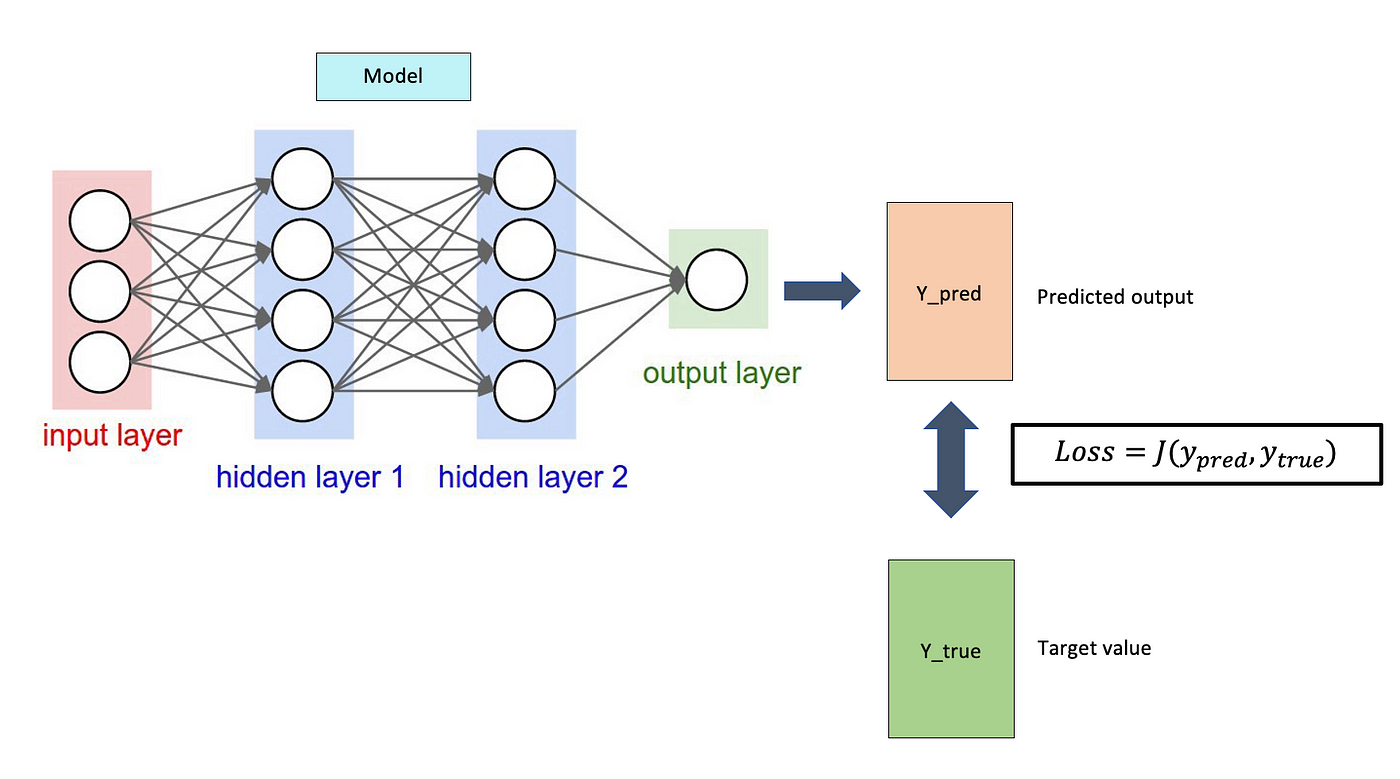
</div>

#### 2. Binary Crossentropy 🔄

**Definition**
Binary Crossentropy measures the distance between two probability distributions for binary classification problems. It quantifies how far the predicted probability is from the actual binary label.

**Formula**
$$Binary\ CE = -\frac{1}{n} \sum_{i=1}^{n} [y_i \log(\hat{y_i}) + (1-y_i) \log(1-\hat{y_i})]$$

Where:
- $y_i \in \{0, 1\}$ = actual binary label
- $\hat{y_i} \in [0, 1]$ = predicted probability

**Keras Implementation**
```python
# Method 1: Using string identifier
model.compile(optimizer='adam', loss='binary_crossentropy')

# Method 2: Using function directly
from tensorflow.keras.losses import BinaryCrossentropy
model.compile(optimizer='adam', loss=BinaryCrossentropy())

# For model with sigmoid activation (last layer)
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
```

**Example & Illustration**
**Scenario**: Email spam detection (0 = Not Spam, 1 = Spam)

```python
import numpy as np

# Example predictions
actual_labels = np.array([1, 0, 1, 0])  # True labels
predicted_probs = np.array([0.9, 0.1, 0.8, 0.3])  # Predicted probabilities

# Manual calculation for one sample
# If actual=1, predicted=0.9: loss = -(1*log(0.9) + 0*log(0.1)) = -log(0.9) ≈ 0.105
# If actual=0, predicted=0.1: loss = -(0*log(0.1) + 1*log(0.9)) = -log(0.9) ≈ 0.105
```

**Visual Representation**
```
Email Classification Results:
Email 1: Actual=Spam(1),     Predicted=0.9 → Low Loss ✅
Email 2: Actual=NotSpam(0),  Predicted=0.1 → Low Loss ✅  
Email 3: Actual=Spam(1),     Predicted=0.8 → Low Loss ✅
Email 4: Actual=NotSpam(0),  Predicted=0.3 → Medium Loss ⚠️

Loss Behavior:
- When prediction matches actual: Loss approaches 0
- When prediction contradicts actual: Loss increases exponentially
```

#### 3. Categorical Crossentropy 🏷️

**Definition**
Categorical Crossentropy measures the distance between predicted and true probability distributions for multi-class classification with one-hot encoded labels. Each sample belongs to exactly one class.

**Formula**
$$Categorical\ CE = -\frac{1}{n} \sum_{i=1}^{n} \sum_{j=1}^{C} y_{i,j} \log(\hat{y_{i,j}})$$

Where:
- $C$ = number of classes
- $y_{i,j}$ = 1 if sample $i$ belongs to class $j$, else 0
- $\hat{y_{i,j}}$ = predicted probability for class $j$

**Keras Implementation**
```python
# Method 1: Using string identifier
model.compile(optimizer='adam', loss='categorical_crossentropy')

# Method 2: Using function directly
from tensorflow.keras.losses import CategoricalCrossentropy
model.compile(optimizer='adam', loss=CategoricalCrossentropy())

# Complete model setup for 3-class classification
model.add(Dense(3, activation='softmax'))  # Output layer
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# Data preparation
from tensorflow.keras.utils import to_categorical
y_categorical = to_categorical(y_labels, num_classes=3)
```

**Example & Illustration**
**Scenario**: Image classification (Cat, Dog, Bird)

```python
import numpy as np

# One-hot encoded labels
actual_labels = np.array([
    [1, 0, 0],  # Cat
    [0, 1, 0],  # Dog
    [0, 0, 1],  # Bird
])

# Predicted probabilities (softmax output)
predicted_probs = np.array([
    [0.8, 0.1, 0.1],  # Correctly predicts Cat
    [0.2, 0.6, 0.2],  # Correctly predicts Dog  
    [0.1, 0.3, 0.6],  # Correctly predicts Bird
])

# Loss calculation for first sample (Cat):
# loss = -(1*log(0.8) + 0*log(0.1) + 0*log(0.1)) = -log(0.8) ≈ 0.223
```

**Visual Representation**
```
Multi-class Classification:
                    Cat   Dog   Bird
Sample 1 (Cat):    [1,    0,    0  ] ← Actual
                   [0.8,  0.1,  0.1] ← Predicted ✅

Sample 2 (Dog):    [0,    1,    0  ] ← Actual  
                   [0.2,  0.6,  0.2] ← Predicted ✅

Sample 3 (Bird):   [0,    0,    1  ] ← Actual
                   [0.1,  0.3,  0.6] ← Predicted ✅

Key: Only the probability for the true class matters in loss calculation
```

#### 4. Sparse Categorical Crossentropy 🎯

**Definition**
Sparse Categorical Crossentropy is identical to Categorical Crossentropy but works with integer labels instead of one-hot encoded labels. It's more memory efficient for problems with many classes.

**Formula**
$$Sparse\ Categorical\ CE = -\frac{1}{n} \sum_{i=1}^{n} \log(\hat{y_{i,y_i}})$$

Where:
- $y_i$ = integer label (class index)
- $\hat{y_{i,y_i}}$ = predicted probability for the true class

**Keras Implementation**
```python
# Method 1: Using string identifier
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

# Method 2: Using function directly
from tensorflow.keras.losses import SparseCategoricalCrossentropy
model.compile(optimizer='adam', loss=SparseCategoricalCrossentropy())

# Complete model setup
model.add(Dense(3, activation='softmax'))  # 3 classes
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# Data format comparison
# Categorical: y = [[1,0,0], [0,1,0], [0,0,1]]
# Sparse:      y = [0, 1, 2]  # Much more memory efficient!
```

**Example & Illustration**
**Scenario**: Text classification (News categories: Sports=0, Politics=1, Tech=2)

```python
import numpy as np

# Integer labels (sparse format)
actual_labels = np.array([0, 1, 2])  # Sports, Politics, Tech

# Predicted probabilities  
predicted_probs = np.array([
    [0.7, 0.2, 0.1],  # Predicts Sports (0)
    [0.1, 0.8, 0.1],  # Predicts Politics (1)
    [0.2, 0.1, 0.7],  # Predicts Tech (2)
])

# Loss calculation:
# Sample 1 (Sports=0): loss = -log(0.7) ≈ 0.357
# Sample 2 (Politics=1): loss = -log(0.8) ≈ 0.223  
# Sample 3 (Tech=2): loss = -log(0.7) ≈ 0.357
```

**Visual Representation**
```
Sparse vs Categorical Comparison:

Integer Labels (Sparse):     [0,    1,    2   ]
One-hot (Categorical):      [[1,0,0], [0,1,0], [0,0,1]]

Memory Usage:
- Sparse: 3 integers = 12 bytes
- Categorical: 9 floats = 36 bytes  
- Savings: 67% less memory! 

Perfect for large vocabularies (NLP) or many classes (ImageNet: 1000 classes)
```

#### 📋 Quick Reference Summary

| Loss Function | Input Format | Output Layer | Use Case |
|--------------|--------------|---------------|----------|
| **MSE** | Continuous values | Linear (no activation) | Predicting continuous numbers (prices, temperatures, ages) |
| **Binary CE** | Binary (0,1) | Sigmoid | Yes/No, True/False, Spam/Not Spam problems |
| **Categorical CE** | One-hot vectors | Softmax | Image classification (few classes), Multiple classes with one-hot encoded labels |
| **Sparse Categorical CE** | Integer labels | Softmax | Text classification (many classes), Multiple classes with integer labels (0, 1, 2, ...) |

#### 🎯 Choosing the Right Loss Function

```python
# Decision Tree:
if problem_type == "regression":
    loss = 'mse'
elif problem_type == "binary_classification":
    loss = 'binary_crossentropy'
elif problem_type == "multi_class":
    if labels_format == "one_hot":
        loss = 'categorical_crossentropy'
    elif labels_format == "integers":
        loss = 'sparse_categorical_crossentropy'
```

**Remember**: The choice of loss function should align with your problem type and data format for optimal training results!

### 🔄 Loss Functions in Forward Propagation

#### The Connection

**Forward propagation** generates predictions, and the **loss function** measures how wrong those predictions are.

#### The Flow

```
Input Data → Hidden Layers → Output Layer → Loss Function → Loss Value
    ↓             ↓              ↓             ↓            ↓
   [X]      [activations]   [predictions]  [compare]    [scalar]
                                    ↓             ↓
                              ŷ (predicted)  y (actual)
```

#### Step-by-Step Process

1. **Forward Pass**: Data flows through network layers
   ```python
   # Neural network forward pass
   x → layer1 → layer2 → ... → output_layer → ŷ (predictions)
   ```

2. **Loss Calculation**: Compare predictions with actual labels
   ```python
   # Loss function takes two inputs
   loss_value = loss_function(y_actual, ŷ_predicted)
   ```

#### Code Example

```python
# Complete forward propagation with loss
import tensorflow as tf

# Forward propagation
predictions = model(X_batch)  # Shape: (batch_size, num_classes)

# Loss calculation (happens automatically during training)
loss_value = loss_function(y_true, predictions)  # Shape: scalar

# What happens internally:
# 1. X_batch flows through all layers
# 2. Final layer outputs predictions  
# 3. Loss function compares predictions vs actual
# 4. Returns single loss value for optimization
```

#### Key Points

- **Loss function is NOT part of the neural network architecture** (not a layer that transforms data)
- **But IS built into the Keras model architecture** - specified during `model.compile()`
- **It's the crucial link between forward and backward propagation**:
  - Forward pass: layers produce predictions
  - Loss function: compares predictions vs actual
  - Backward pass: uses loss gradients to update weights
- **Output layer activation must match loss function**:
  - `sigmoid` + `binary_crossentropy`
  - `softmax` + `categorical_crossentropy`  
  - `linear` + `mse`

#### Visual Summary

```
┌─────────────────────────────────────┐
│         FORWARD PROPAGATION         │
├─────────────────────────────────────┤
│ Input → Hidden → Hidden → Output    │
│  [X]     [h1]     [h2]     [ŷ]     │
└─────────────────────┬───────────────┘
                      │
                      ▼
┌─────────────────────────────────────┐
│           LOSS FUNCTION             │
├─────────────────────────────────────┤
│  Loss = f(y_actual, ŷ_predicted)    │
│         ↓                           │
│    [scalar value]                   │
└─────────────────────────────────────┘
```

**Bottom Line**: Forward propagation creates predictions; loss functions measure prediction quality.

### **🧠 Knowledge Check Questions - Section 2.2.1**

**Question 1:** You're building a model to predict a person's age (in years) from their photo. Which loss function should you use and why?

<details>
<summary>Click for answer</summary>

**Mean Squared Error (MSE)** because age is a continuous numerical value (regression problem). We want to minimize the squared difference between predicted and actual age.
</details>

**Question 2:** Why does Binary Crossentropy work better than MSE for classification problems?

<details>
<summary>Click for answer</summary>

Binary Crossentropy is designed to measure the distance between probability distributions. It heavily penalizes confident wrong predictions and works naturally with sigmoid outputs (0-1 probabilities). MSE treats classification as regression, which doesn't match the problem structure.
</details>

**Question 3:** What's the difference between Categorical Crossentropy and Sparse Categorical Crossentropy?

<details>
<summary>Click for answer</summary>

Both solve multi-class classification, but:
- **Categorical Crossentropy**: Expects one-hot encoded labels `[0, 1, 0]`
- **Sparse Categorical Crossentropy**: Expects integer labels `1`
Sparse is more convenient as you don't need to one-hot encode your labels.
</details>

**Question 4:** A model predicts 0.9 probability for the positive class, but the true label is 0 (negative). Will this have a high or low Binary Crossentropy loss?

<details>
<summary>Click for answer</summary>

**Very high loss!** The model is confidently wrong (90% sure it's positive when it's actually negative). Binary Crossentropy heavily penalizes confident incorrect predictions.
</details>

## **2.2.2 Backpropagation: Conceptual Intuition**
*Estimated Time: 25 minutes*

### 1. Definition

**Backpropagation** (backward propagation of errors) is the algorithm that computes gradients of the loss function with respect to each weight in the neural network. It determines how much each weight contributed to the total error and calculates how to adjust them to minimize future errors.

**In simple terms**: It's how the neural network learns by figuring out which weights to blame for mistakes and how to fix them.

### 2. Idea & Intuition 💡

#### The Cooking Analogy
Imagine you're adjusting a recipe:
- **Forward Pass**: You cook the dish (make predictions)
- **Loss Function**: You taste it and measure how far off it is from perfect
- **Backpropagation**: You figure out which ingredients (weights) to adjust and by how much

#### The Blame Game
```
🎯 Target: Perfect prediction
❌ Reality: Network made an error
🔍 Question: Which weights caused this error?
📊 Answer: Backpropagation assigns "blame" to each weight proportionally
```

#### Key Insight
**Backpropagation is reverse engineering**: Starting from the final error, work backward to see how each weight contributed to that error.

### 3. Connection to Forward Propagation & Loss Function 🔄

#### The Complete Learning Cycle
<div align="center">
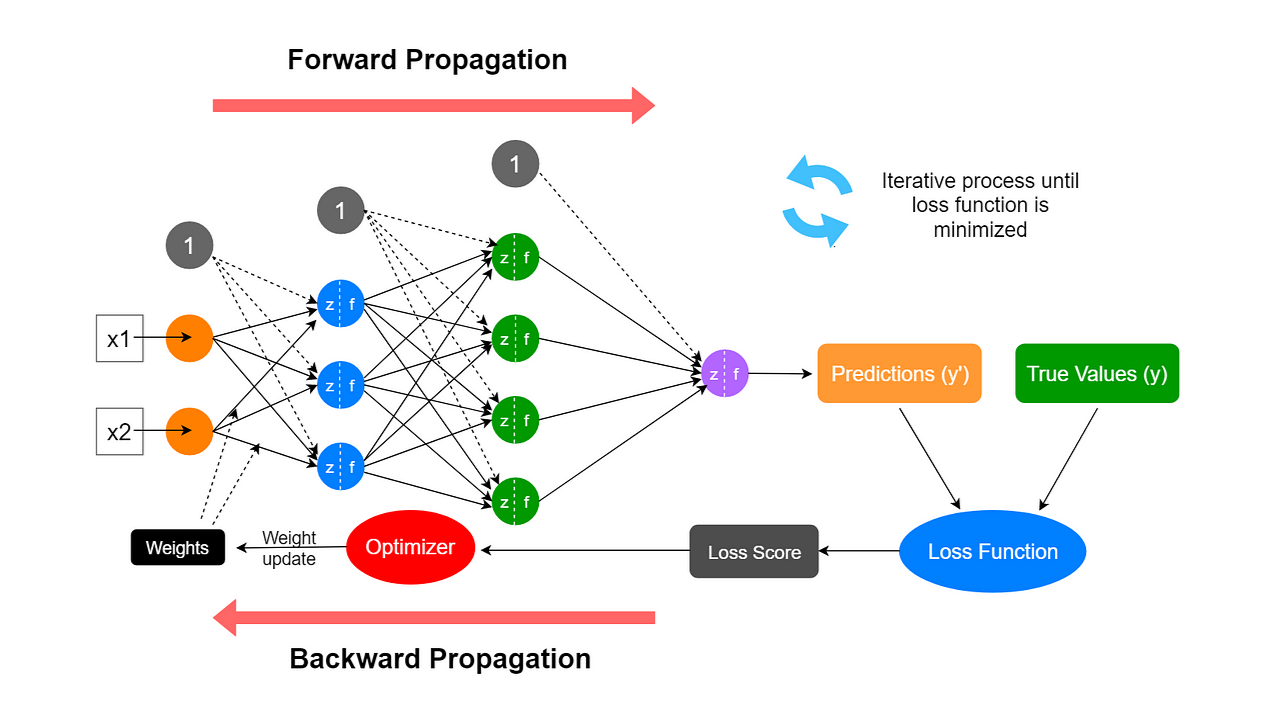
</div>

#### Dependencies
1. **Forward propagation** creates predictions and stores intermediate activations
2. **Loss function** measures the error and provides initial gradient
3. **Backpropagation** uses stored activations and loss gradient to compute weight gradients
4. **Optimizer** updates weights using computed gradients

#### Why This Order Matters
```python
# This is what happens in each training step:
predictions = model(X)              # Forward: compute predictions
loss = loss_function(y, predictions) # Loss: measure error  
gradients = compute_gradients(loss)   # Backward: find blame
optimizer.apply_gradients(gradients) # Update: fix weights
```

### 4. The Backpropagation Process 📋

#### Step-by-Step Walkthrough

```
Network: Input → Hidden1 → Hidden2 → Output
Process: Hidden1 ← Hidden2 ← Hidden1 Output ← (gradients flow backward)
```

##### Step 1: Start at Output Layer
- Compute gradient of loss with respect to output predictions
- This tells us: "How should the final predictions change?"

##### Step 2: Work Backward Through Each Layer
For each layer (from output to input):
1. **Compute local gradients**: How does this layer's output affect the loss?
2. **Apply chain rule**: Combine with gradients from layers ahead
3. **Compute weight gradients**: How should this layer's weights change?
4. **Pass gradients backward**: Send gradients to the previous layer

##### Step 3: Accumulate Gradients
- Collect gradients for all weights across all layers
- These gradients point in the direction of steepest increase in loss
- We'll move weights in the opposite direction to decrease loss

#### Visual Process Flow
```
Layer:     Input  →  Hidden1  →  Hidden2  →  Output
Forward:   X      →  h1       →  h2       →  ŷ
           
Loss = f(y, ŷ)

Backward:  ∂L/∂X  ←  ∂L/∂h1   ←  ∂L/∂h2   ←  ∂L/∂ŷ
Gradients: (skip)    ∂L/∂W1      ∂L/∂W2      ∂L/∂W3
```

### 5. Mathematics & Formulas 📐

#### The Chain Rule Foundation
The chain rule is the mathematical foundation of backpropagation:

$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial z} \cdot \frac{\partial z}{\partial w}$$

Where:
- $L$ = loss function
- $w$ = weight
- $z$ = weighted sum (before activation)

#### For a Single Layer
Consider a layer with:
- Input: $x$
- Weights: $W$
- Bias: $b$  
- Weighted sum: $z = Wx + b$
- Activation: $a = f(z)$ where $f$ is activation function

**Gradient computations:**

$$\frac{\partial L}{\partial W} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial W}$$

$$\frac{\partial L}{\partial b} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial z}$$

$$\frac{\partial L}{\partial x} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial x}$$

#### Concrete Example
**Network**: Input(1) → Dense(1) → Output
- Weight: $w = 0.5$
- Input: $x = 2.0$
- Target: $y = 3.0$
- Prediction: $\hat{y} = w \cdot x = 0.5 \times 2.0 = 1.0$
- Loss (MSE): $L = \frac{1}{2}(y - \hat{y})^2 = \frac{1}{2}(3-1)^2 = 2.0$

**Backpropagation calculation:**
$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial w}$$

$$\frac{\partial L}{\partial \hat{y}} = -(y - \hat{y}) = -(3-1) = -2$$

$$\frac{\partial \hat{y}}{\partial w} = x = 2$$

$$\frac{\partial L}{\partial w} = -2 \times 2 = -4$$

**Update rule**: $w_{new} = w_{old} - \alpha \frac{\partial L}{\partial w} = 0.5 - 0.1 \times (-4) = 0.9$

### 6. Keras Model Architecture & Code 💻

#### Automatic Backpropagation in Keras

```python
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Build model architecture
model = Sequential([
    Dense(64, activation='relu', input_shape=(10,)),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')  # Regression output
])

# Compile with optimizer (handles backpropagation)
model.compile(
    optimizer=Adam(learning_rate=0.001),  # Optimizer uses gradients
    loss='mse',                           # Loss function for gradients
    metrics=['mae']
)
```

#### What Happens During Training

```python
# Training loop (what model.fit() does internally)
for epoch in range(epochs):
    for batch in dataset:
        X_batch, y_batch = batch
        
        # 1. Forward propagation (automatic)
        with tf.GradientTape() as tape:
            predictions = model(X_batch, training=True)
            loss_value = loss_function(y_batch, predictions)
        
        # 2. Backward propagation (automatic)
        gradients = tape.gradient(loss_value, model.trainable_variables)
        
        # 3. Weight update (automatic)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
```

#### Training with Different Optimizers

```python
# Different optimizers handle gradients differently
optimizers = {
    'sgd': tf.keras.optimizers.SGD(learning_rate=0.01),
    'adam': tf.keras.optimizers.Adam(learning_rate=0.001),
    'rmsprop': tf.keras.optimizers.RMSprop(learning_rate=0.001)
}

# All use the same backpropagated gradients but apply them differently
for name, optimizer in optimizers.items():
    model.compile(optimizer=optimizer, loss='mse')
    # Backpropagation algorithm is the same, only weight updates differ
```

### 📊 Visual Summary: The Complete Picture

```
🔄 THE NEURAL NETWORK LEARNING CYCLE

┌─────────────────────────────────────────────────────────┐
│                   FORWARD PROPAGATION                   │
│   Input → Layer1 → Layer2 → ... → Output → Predictions │
│    [X]     [h1]     [h2]           [ŷ]                 │
└─────────────────────┬───────────────────────────────────┘
                      │
                      ▼
┌─────────────────────────────────────────────────────────┐
│                   LOSS CALCULATION                     │
│              Loss = f(y_actual, ŷ_predicted)            │
│                     [scalar value]                     │
└─────────────────────┬───────────────────────────────────┘
                      │
                      ▼
┌─────────────────────────────────────────────────────────┐
│                  BACKWARD PROPAGATION                   │
│   ∂L/∂W ← Layer1 ← Layer2 ← ... ← Output ← ∂L/∂ŷ        │
│ [gradients] [∂L/∂h1] [∂L/∂h2]       [∂L/∂output]       │
└─────────────────────┬───────────────────────────────────┘
                      │
                      ▼
┌─────────────────────────────────────────────────────────┐
│                    WEIGHT UPDATE                        │
│              W_new = W_old - α × ∂L/∂W                  │
│                [optimizer applies gradients]            │
└─────────────────────────────────────────────────────────┘
```

### 🎯 Key Takeaways

1. **Backpropagation = Gradient Computation**: It calculates how to adjust each weight
2. **Chain Rule Powers Everything**: Mathematical foundation for gradient flow
3. **Automatic in Keras**: You just specify architecture, loss, and optimizer
4. **Memory Requirements**: Must store forward pass activations for backward pass
5. **Optimization Bridge**: Connects loss measurement to weight improvements

**Remember**: Backpropagation doesn't update weights directly - it computes gradients. The optimizer uses these gradients to actually update the weights! 

### **🏈 The Champion Sports Team Analogy**

Imagine you're coaching a football team that just lost a game. How do you figure out what each player needs to improve?

**🎯 The Coaching Process (= Backpropagation):**

1. **📊 Analyze the Final Score (Loss Calculation)**
   - Game ends with a disappointing loss
   - You know the total "error" but not who's responsible

2. **🎬 Review Game Film Backwards (Backpropagation Starts)**
   - Start with the final play that lost the game
   - Work backwards through each play

3. **🔍 Assign Responsibility (Gradient Calculation)**
   - **Quarterback:** Threw the interception → High blame for final loss
   - **Offensive Line:** Missed blocks → Medium blame (enabled the pressure)
   - **Wide Receivers:** Ran wrong routes → Lower blame but still contributed
   - **Defense:** Poor field position given → Indirect blame

4. **📝 Individual Coaching Notes (Weight Updates)**
   - Each player gets specific feedback on what to improve
   - Players directly involved in the loss get more intense coaching
   - Everyone gets some adjustment, but proportional to their impact

### **🧠 The Mathematical Magic (Without Heavy Math)**

**The Core Challenge:** 
We have a loss value at the end of the network. How do we know how to adjust a specific weight buried deep inside the network to reduce that final loss?

**Backpropagation's Brilliant Solution:**

In [3]:
# Code cell demonstrating backpropagation concept
def backpropagation_intuition():
    print("🔄 Backpropagation: The Blame Assignment Algorithm")
    print("=" * 50)
    
    # Simplified 3-layer network example
    print("Network: Input → Hidden → Output")
    print("Prediction: 0.8 (but true label was 0)")
    print("Loss: High! (confident wrong prediction)")
    
    print("\n🔄 BACKWARD PASS - Assigning Blame:")
    
    print("\n📤 Step 1: Output Layer Analysis")
    print("   🎯 Question: How much did the output neuron contribute to this error?")
    print("   📊 Answer: A LOT! It output 0.8 when it should have been close to 0")
    print("   📝 Blame Score (Gradient): HIGH → Large weight adjustments needed")
    
    print("\n🔄 Step 2: Hidden Layer Analysis")
    print("   🎯 Question: How much did each hidden neuron contribute?")
    print("   📊 Answer: Depends on their connection strength to the output")
    print("   📝 Blame Calculation:")
    print("      - Hidden neuron with strong positive connection → High blame")
    print("      - Hidden neuron with weak connection → Low blame")
    print("      - Hidden neuron that was inactive (ReLU=0) → No blame")
    
    print("\n📥 Step 3: Input Layer Connections")
    print("   🎯 Question: How much did each input connection contribute?")
    print("   📊 Answer: Traced back through the hidden layer blame scores")
    print("   📝 Final Result: Every weight gets a specific 'improvement direction'")
    
    print("\n✨ The Magic:")
    print("   🎯 Each weight knows EXACTLY how to change to reduce the loss")
    print("   📊 Change size is proportional to responsibility for the error")
    print("   🔄 This happens for EVERY weight in the network simultaneously!")

backpropagation_intuition()

🔄 Backpropagation: The Blame Assignment Algorithm
Network: Input → Hidden → Output
Prediction: 0.8 (but true label was 0)
Loss: High! (confident wrong prediction)

🔄 BACKWARD PASS - Assigning Blame:

📤 Step 1: Output Layer Analysis
   🎯 Question: How much did the output neuron contribute to this error?
   📊 Answer: A LOT! It output 0.8 when it should have been close to 0
   📝 Blame Score (Gradient): HIGH → Large weight adjustments needed

🔄 Step 2: Hidden Layer Analysis
   🎯 Question: How much did each hidden neuron contribute?
   📊 Answer: Depends on their connection strength to the output
   📝 Blame Calculation:
      - Hidden neuron with strong positive connection → High blame
      - Hidden neuron with weak connection → Low blame
      - Hidden neuron that was inactive (ReLU=0) → No blame

📥 Step 3: Input Layer Connections
   🎯 Question: How much did each input connection contribute?
   📊 Answer: Traced back through the hidden layer blame scores
   📝 Final Result: Every weight gets

### **🎭 Why This Works: The "Chain of Responsibility"**

In [4]:
# Code cell showing chain rule intuition
def chain_rule_intuition():
    print("⛓️ The Chain of Responsibility")
    print("=" * 30)
    
    print("🎯 Example: Why did the final prediction go wrong?")
    print()
    
    print("📈 Forward Pass (What Happened):")
    print("   Input → [Hidden Layer] → [Output Layer] → Wrong Prediction")
    print()
    
    print("🔄 Backward Pass (Finding Responsibility):")
    print("   1. Output was wrong because output weights were bad")
    print("   2. Output weights were bad because hidden layer values were bad")
    print("   3. Hidden values were bad because hidden weights were bad")
    print("   4. Hidden weights were bad because... (and so on)")
    print()
    
    print("🧠 Chain Rule Magic:")
    print("   Each layer's error = Next layer's error × Connection strength")
    print("   This creates a 'blame chain' from output to input")
    print()
    
    print("💡 Result:")
    print("   Every weight gets feedback on its specific contribution")
    print("   Weights that caused more error get bigger adjustments")
    print("   The network learns efficiently from its mistakes!")

chain_rule_intuition()

⛓️ The Chain of Responsibility
🎯 Example: Why did the final prediction go wrong?

📈 Forward Pass (What Happened):
   Input → [Hidden Layer] → [Output Layer] → Wrong Prediction

🔄 Backward Pass (Finding Responsibility):
   1. Output was wrong because output weights were bad
   2. Output weights were bad because hidden layer values were bad
   3. Hidden values were bad because hidden weights were bad
   4. Hidden weights were bad because... (and so on)

🧠 Chain Rule Magic:
   Each layer's error = Next layer's error × Connection strength
   This creates a 'blame chain' from output to input

💡 Result:
   Every weight gets feedback on its specific contribution
   Weights that caused more error get bigger adjustments
   The network learns efficiently from its mistakes!


### **🚨 Common Backpropagation Misconceptions**

**❌ Myth:** "The network tries random changes until something works"  
**✅ Truth:** Backpropagation calculates the *exact direction* each weight should change

**❌ Myth:** "It's too complex to understand without heavy math"  
**✅ Truth:** It's fundamentally about *tracing responsibility* for errors

**❌ Myth:** "Each weight learns independently"  
**✅ Truth:** All weights are *coordinated* through the shared error signal

### **🧠 Knowledge Check Questions - Section 2.2.2**

**Question 1:** In the sports team analogy, what does the "quarterback throwing an interception" represent in neural network terms?

<details>
<summary>Click for answer</summary>

The **output layer producing a very wrong prediction**. Just like the quarterback's interception directly caused the loss, the output layer's wrong prediction directly creates the high loss that needs to be corrected.
</details>

**Question 2:** Why does backpropagation work backwards through the network instead of forwards?

<details>
<summary>Click for answer</summary>

Because we know the **error at the output** and need to trace how each earlier layer contributed to that error. Working backwards lets us use the chain rule to calculate exactly how much blame each weight deserves for the final mistake.
</details>

**Question 3:** If a hidden neuron has a very strong connection (large weight) to an output neuron that made a big error, will this hidden neuron receive high or low blame?

<details>
<summary>Click for answer</summary>

**High blame!** Strong connections mean high responsibility. If the output neuron made a big error and this hidden neuron strongly influenced it, then the hidden neuron bears significant responsibility for the mistake.
</details>

**Question 4:** True or False: During backpropagation, weights are actually updated as the algorithm moves backward through the layers.

<details>
<summary>Click for answer</summary>

**False!** Backpropagation only *calculates* the gradients (blame scores). The actual weight updates happen afterward during the optimization step. Backpropagation is purely about figuring out *what* to change, not *making* the changes.
</details>

## **📝 Summary & Transition to Note 2.3**

### **🎯 What We've Mastered in Note 2.2:**

✅ **Loss Functions:** The "report card" that measures prediction quality  
✅ **Problem Matching:** How to choose the right loss for your task  
✅ **Backpropagation:** The "blame assignment" algorithm that traces errors  
✅ **Mathematical Intuition:** Why these loss functions work so well  

### **🔗 The Learning Puzzle So Far:**

We now understand:
- **📊 How to measure wrongness** (Loss Functions)
- **🔄 How to assign blame** (Backpropagation)
- **🧠 Why these methods work** (Mathematical foundations)

But one crucial piece remains:

🤔 **"We know WHAT needs to change and by HOW MUCH... but HOW do we actually make those changes? How do we turn gradients into better weights?"**

### **🚀 Coming Up in Note 2.3: Optimization**

The final piece of the learning puzzle:
- **How do optimizers update weights?** → SGD, Adam, RMSprop
- **What's a learning rate and why does it matter?** → Step size control
- **How do we put it all together?** → The complete training cycle

**The Journey Continues:** We know the score and who's to blame... now let's learn how to improve! 🎯⚡

**⏰ Time Check:** Note 2.2 Complete (1.0 hour)  
**🎯 Next:** Note 2.3 - Optimization (0.5 hour)  
**📈 Progress:** 2/4 notes complete for Day 2